# Exercises XP GOLD

## 👩‍🏫 👩🏿‍🏫 What You’ll Learn

* Advanced visualization techniques using Python libraries like Matplotlib and Seaborn.
* How to manipulate and analyze hierarchical data in pandas.
* Techniques for filtering and querying data in complex datasets.
* Methods for exploring relationships and distributions in data using visualizations.


## 🛠️ What You Will Create

* Customized bar graphs, box plots, and distribution plots for various datasets.
* Hierarchical indexing solutions for filtering specific data.
* Pair plots to explore relationships between financial data metrics.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

In [3]:
#@title 🔄 Colab & Local Jupyter Folder Switcher (click to expand)

# 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
# 🚨        Change only this 🚨
relative_path = "_datasets" #🚨 any relative path
# 🚨        Change only this 🚨
# 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨

import os

create_if_missing = True      # False = error if folder missing

def in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

def paths_equal(a: str, b: str) -> bool:
    """Portable path equality (no os.path.samepath)."""
    return os.path.normcase(os.path.realpath(a)) == os.path.normcase(os.path.realpath(b))

def resolve_local_base(rel_path: str) -> str:
    pinned = os.getenv("NOTEBOOK_ROOT")
    if pinned:
        return pinned
    cwd = os.path.abspath(os.getcwd())
    rel_name = os.path.basename(os.path.normpath(rel_path))
    base = os.path.dirname(cwd) if rel_name and os.path.basename(cwd) == rel_name else cwd
    os.environ["NOTEBOOK_ROOT"] = base
    return base

def resolve_colab_base(rel_path: str) -> str:
    pinned = os.getenv("COLAB_ROOT")
    if pinned:
        return pinned
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    mydrive = "/content/drive/MyDrive"
    colab_nb = os.path.join(mydrive, "Colab Notebooks")
    base = colab_nb if os.path.isdir(colab_nb) else mydrive
    os.environ["COLAB_ROOT"] = base
    return base

# --- Pick base path ---
if in_colab():
    print("✅ Detected Google Colab")
    base_path = resolve_colab_base(relative_path)
else:
    print("✅ Detected Local Jupyter")
    base_path = resolve_local_base(relative_path)

# --- Build target path ---
if os.path.isabs(relative_path):
    target_path = os.path.abspath(relative_path)
else:
    target_path = os.path.abspath(os.path.join(base_path, relative_path))

current = os.path.abspath(os.getcwd())
rel_name = os.path.basename(os.path.normpath(relative_path))
if rel_name and os.path.basename(current) == rel_name:
    target_path = current

# --- Ensure exists ---
if not os.path.exists(target_path):
    if create_if_missing:
        os.makedirs(target_path, exist_ok=True)
        print(f"📁 Created folder: {target_path}")
    else:
        raise FileNotFoundError(f"❌ Path does not exist: {target_path}")

# --- Change only if needed ---
if paths_equal(current, target_path):
    print(f"📂 Already working in: {current}")
else:
    os.chdir(target_path)
    print(f"📂 Now working in: {os.path.abspath(os.getcwd())}")


✅ Detected Local Jupyter
📂 Now working in: /Users/jayklarin/Documents/__DI/Repositories/di_bootcamp/Colab-Swap/_datasets


In [4]:
df = pd.read_csv('Tweets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


## Exercise 1: Bar Graph

**Objective**: Create a bar graph representing the sales data of a retail company.

**Tasks**:
* Use a fictional dataset where the x-axis represents product categories and the y-axis represents total sales amounts.
* Customize the bar graph with appropriate labels for the axes, a title, and color.
* Display the graph using ```Matplotlib```.

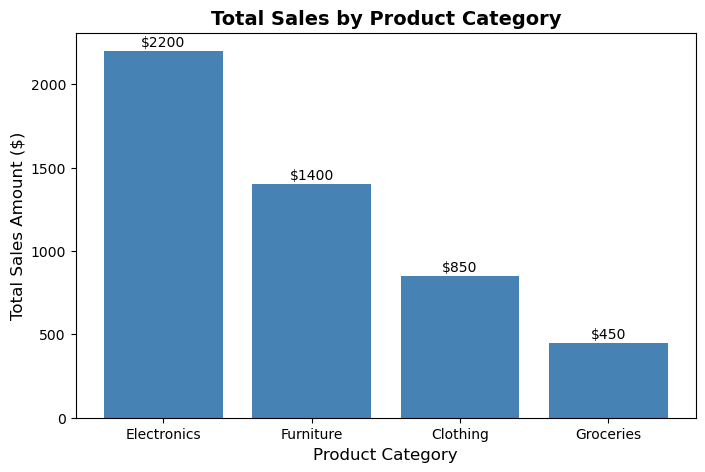

In [6]:
# ------------------------------
# Step 1: Create a fictional dataset
# ------------------------------
dict = {
    "Transaction ID": range(1, 11),
    "Product Category": [
        "Electronics", "Clothing", "Groceries", "Clothing", "Electronics",
        "Furniture", "Groceries", "Furniture", "Electronics", "Clothing"
    ],
    "Total Amount": [500, 200, 150, 400, 700, 800, 300, 600, 1000, 250]
}

df = pd.DataFrame(dict)

# ------------------------------
# Step 2: Aggregate sales by category
# ------------------------------
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

# ------------------------------
# Step 3: Plot the bar graph
# ------------------------------
plt.figure(figsize=(8, 5))
bars = plt.bar(category_sales.index, category_sales.values, color="steelblue")

# Add labels, title
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Sales Amount ($)", fontsize=12)
plt.title("Total Sales by Product Category", fontsize=14, fontweight="bold")

# Optional: Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10,
             f"${height}", ha="center", va="bottom", fontsize=10)

plt.show()

## Exercise 2: Hierarchical Indexing

**Objective**: Filter and retrieve all days when the temperature exceeded 30°C (86°F) for cities in Canada using hierarchical indexing.

**Tasks**:
* Create a pandas DataFrame with hierarchical indexing on ‘Country’, ‘City’, and ‘Date’.
* Write Python code to filter the dataset for the specified condition.
* Explain how hierarchical indexing simplifies multi-level data analysis.

In [8]:
# ------------------------------
# Step 1: Create a dataset
# ------------------------------
dict = {
    ("Canada", "Toronto", "2025-07-01"): 28,
    ("Canada", "Toronto", "2025-07-02"): 31,
    ("Canada", "Toronto", "2025-07-03"): 29,
    ("Canada", "Vancouver", "2025-07-01"): 25,
    ("Canada", "Vancouver", "2025-07-02"): 33,
    ("Canada", "Vancouver", "2025-07-03"): 27,
    ("USA", "New York", "2025-07-01"): 34,
    ("USA", "New York", "2025-07-02"): 29,
}

# Convert dictionary → DataFrame with MultiIndex
index = pd.MultiIndex.from_tuples(dict.keys(), names=["Country", "City", "Date"])
df = pd.DataFrame({"Temperature (°C)": list(dict.values())}, index=index)

df

Temperature (°C)
Country City      Date                        
Canada  Toronto   2025-07-01                28
                  2025-07-02                31
                  2025-07-03                29
        Vancouver 2025-07-01                25
                  2025-07-02                33
                  2025-07-03                27
USA     New York  2025-07-01                34
                  2025-07-02                29

In [9]:
# ------------------------------
# Step 2: Filtering
# ------------------------------
# Select only Canada
canada_df = df.loc["Canada"]

# Filter rows where temp > 30
hot_days = canada_df[canada_df["Temperature (°C)"] > 30]

hot_days

,,Temperature (°C)
City,Date,
Toronto,2025-07-02,31
Vancouver,2025-07-02,33


## Exercise 3: Advanced Filtering With Hierarchical Indices

**Objective**: Filter rows in a hierarchical DataFrame based on specific criteria.

**Tasks**:
* Use the DataFrame from Exercise 4 of the XP exercises.
* Write Python code to filter and display rows where ‘Salary’ is above 50,000 within each ‘Department’.
* Demonstrate how hierarchical indexing facilitates efficient filtering.

In [11]:
# ------------------------------
# Step 1: Sample DataFrame
# ------------------------------
data = {
    ("IT", "Alice"): {"Salary": 60000, "Age": 28},
    ("IT", "Bob"): {"Salary": 45000, "Age": 32},
    ("HR", "Carol"): {"Salary": 52000, "Age": 41},
    ("HR", "Dan"): {"Salary": 48000, "Age": 37},
    ("Finance", "Eve"): {"Salary": 70000, "Age": 29},
    ("Finance", "Frank"): {"Salary": 40000, "Age": 33},
}

# Convert to MultiIndex DataFrame
index = pd.MultiIndex.from_tuples(data.keys(), names=["Department", "Employee"])
df = pd.DataFrame(data.values(), index=index)

df

Salary  Age
Department Employee             
IT         Alice      60000   28
           Bob        45000   32
HR         Carol      52000   41
           Dan        48000   37
Finance    Eve        70000   29
           Frank      40000   33

In [12]:
# ------------------------------
# Step 2: Filtering
# ------------------------------
high_salary = df[df["Salary"] > 50000]
high_salary

,,Salary,Age
Department,Employee,,
IT,Alice,60000,28
HR,Carol,52000,41
Finance,Eve,70000,29


In [13]:
# Beyond the scope of the assignment

# turn the row MultiIndex (Department, Employee) into normal columns
flat = df.reset_index()

# now our columns are: ['Department', 'Employee', 'Salary', 'Age']
flat

,Department,Employee,Salary,Age
0,IT,Alice,60000,28
1,IT,Bob,45000,32
2,HR,Carol,52000,41
3,HR,Dan,48000,37
4,Finance,Eve,70000,29
5,Finance,Frank,40000,33


## Exercise 4: Visualizing Movie Durations

**Objective**: Create a distribution plot to visualize the durations of MCU movies.

**Tasks**:
* Import necessary libraries (pandas, Seaborn, Matplotlib).
* Load a dataset containing MCU movie information.
* Use Seaborn’s ```distplot``` or ```histplot``` to visualize the distribution of movie durations.
* Add a KDE overlay and customize the plot with a title.
* Display the plot.

In [15]:
df = pd.read_csv('mcu_box_office.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   movie_title           27 non-null     object
 1   mcu_phase             27 non-null     int64 
 2   release_date          27 non-null     object
 3   tomato_meter          27 non-null     int64 
 4   audience_score        27 non-null     int64 
 5   movie_duration        27 non-null     int64 
 6   production_budget     27 non-null     object
 7   opening_weekend       27 non-null     object
 8   domestic_box_office   27 non-null     object
 9   worldwide_box_office  27 non-null     object
dtypes: int64(4), object(6)
memory usage: 2.2+ KB


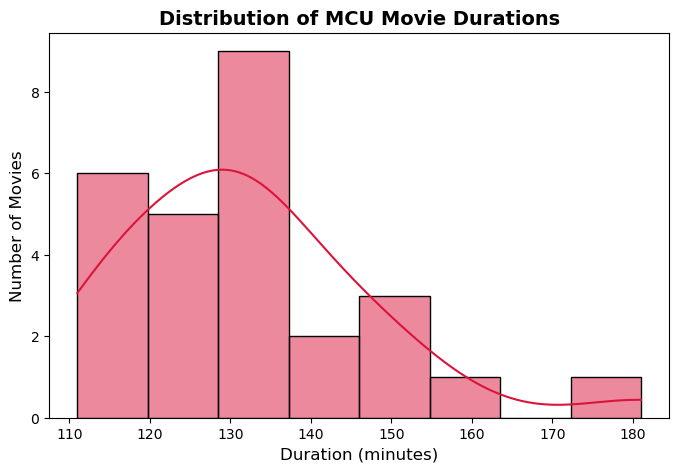

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["movie_duration"],
    bins=8,              # adjust bin size as needed
    kde=True,            # overlay KDE curve
    color="crimson"      # bar color
)

plt.title("Distribution of MCU Movie Durations", fontsize=14, fontweight="bold")
plt.xlabel("Duration (minutes)", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)

plt.show()

## Exercise 5: Box Plot Of Audience And Tomato Meter Scores

**Objective**: Compare the distribution of Tomato Meter scores and Audience scores using a box plot.

**Tasks**:
* Create a new DataFrame that melts the Tomato Meter and Audience scores into a long format.
* Use Seaborn’s ```boxplot``` to visualize the distributions of both scores.
* Customize the plot by setting an appropriate color palette and adding a title.
* Display the plot.

In [18]:
scores = df[["tomato_meter", "audience_score"]]

In [19]:
# Step 3: Melt into Long Format
# -----------------------------------------------
# We currently have a wide format DataFrame like:
#   tomato_meter   audience_score
#   95             88
#   87             92
#   ...
#
# Seaborn's boxplot works best when data is in *long format*:
#   Score Type     Score
#   tomato_meter   95
#   audience_score 88
#   ...
#
# The .melt() function reshapes the DataFrame:
# - var_name="Score Type"  → creates a new column holding the original column names
# - value_name="Score"     → creates a new column holding the values
#
long_scores = scores.melt(
    var_name="Score Type",   # column will hold 'tomato_meter' and 'audience_score'
    value_name="Score"       # column will hold the numeric score values
)

long_scores.head()

,Score Type,Score
0,tomato_meter,94
1,tomato_meter,67
2,tomato_meter,72
3,tomato_meter,77
4,tomato_meter,79


/var/folders/gz/0c41mw6j22x4rm3rkhgx2_3h0000gn/T/ipykernel_30883/2920190925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


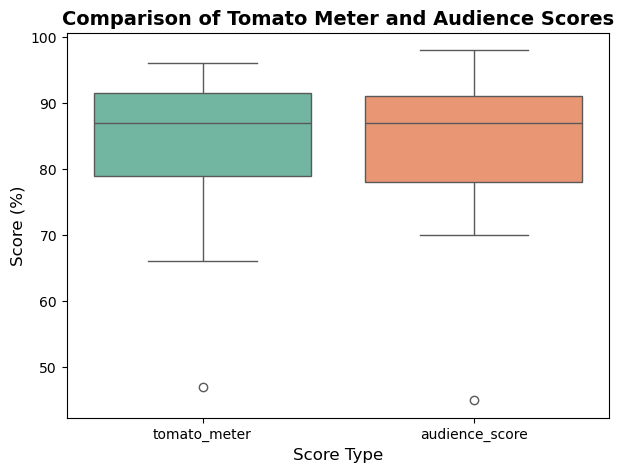

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=long_scores,
    x="Score Type", 
    y="Score",
    palette="Set2"   # you can try "coolwarm", "pastel", etc.
)

plt.title("Comparison of Tomato Meter and Audience Scores", fontsize=14, fontweight="bold")
plt.xlabel("Score Type", fontsize=12)
plt.ylabel("Score (%)", fontsize=12)

plt.show()

## Exercise 6: Pair Plot Of Financial Data

**Objective**: Use Seaborn’s ```pairplot``` to explore relationships between financial aspects of MCU movies.

**Tasks**:
* Select relevant columns for analysis (e.g., Production Budget, Opening Weekend, Domestic Box Office, Worldwide Box Office).
* Convert financial data from string to numeric if needed.
* Use Seaborn’s ```pairplot``` to visualize pairwise relationships between the selected metrics.
* Set ```hue``` based on the MCU phase (e.g., ```mcu_phase```) to identify patterns related to movie phases.
* Customize the plot and display it.

In [22]:
# Columns: production_budget, opening_weekend, domestic_box_office, worldwide_box_office

# Helper function to strip $ and commas, then convert to int
def clean_money(series):
    return series.replace('[\$,]', '', regex=True).astype(float)

# Apply cleaning to financial columns
financial_cols = ["production_budget", "opening_weekend", "domestic_box_office", "worldwide_box_office"]
df[financial_cols] = df[financial_cols].apply(clean_money)

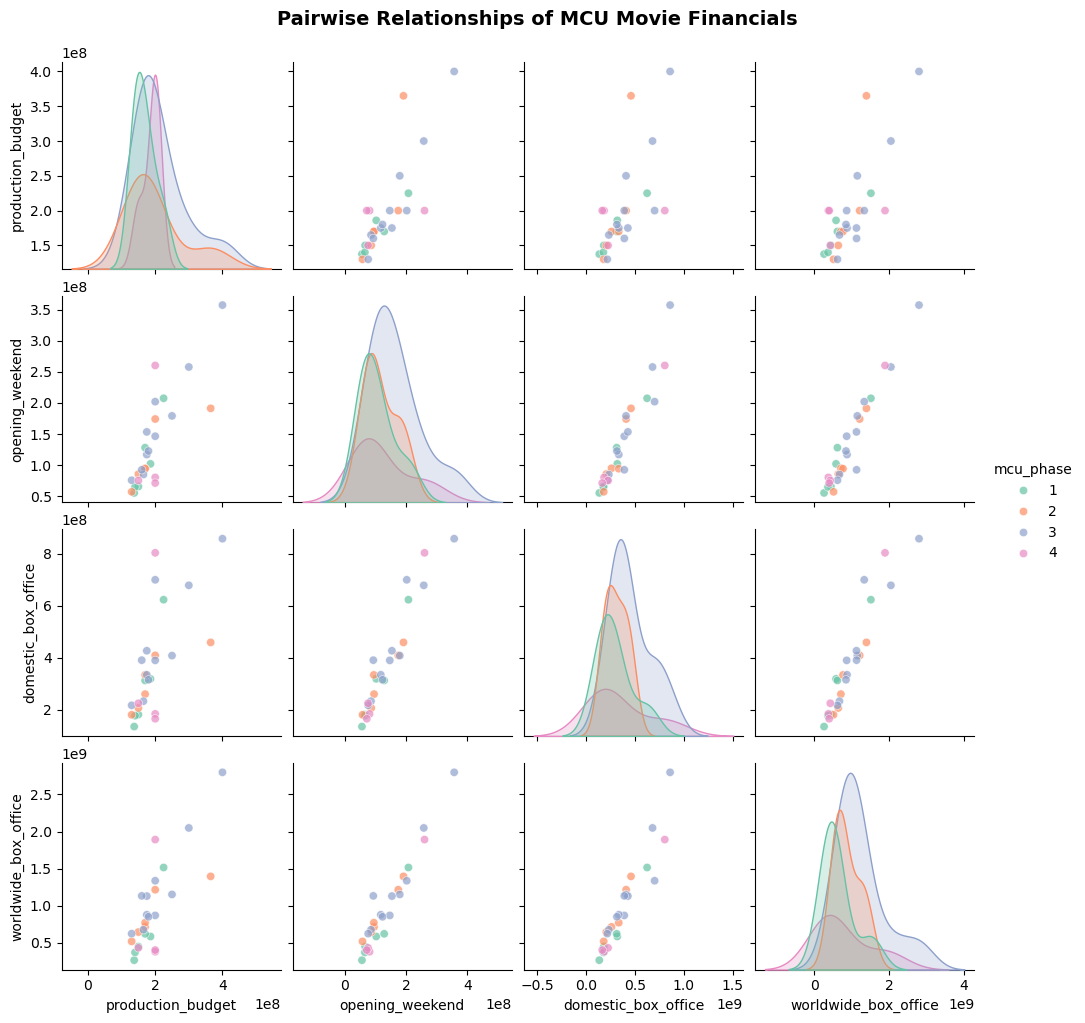

In [23]:
# Select relevant columns + mcu_phase for coloring
pairplot_df = df[financial_cols + ["mcu_phase"]]

# Create pairplot
sns.pairplot(
    data=pairplot_df,
    vars=financial_cols,
    hue="mcu_phase",          # color points by MCU phase
    palette="Set2",           # nice color scheme
    diag_kind="kde",          # KDE curve on diagonals
    plot_kws={"alpha":0.7}    # make points slightly transparent
)

plt.suptitle("Pairwise Relationships of MCU Movie Financials", y=1.02, fontsize=14, fontweight="bold")
plt.show()